# DPL Plots

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


## Confusion Matrix Plotting

In [9]:
experiment_name = "darpa_neg_scratch_down_w10"
file_path = f"../experiments/darpa2000/s1_inside/deepproblog/darpa_neg/cms/{experiment_name}_20260326_150943.npz"

In [10]:
data = np.load(file_path, allow_pickle=True)

mat = data["confusion_matrix"]
classes = data["classes"].tolist()
metrics = data["metrics"].item()

In [11]:
def compute_masks(cm, classes):
    n = len(classes)
    benign_idx = classes.index("benign")

    diag_mask = np.eye(n, dtype=bool)

    fp_mask = np.zeros_like(cm, dtype=bool)
    fn_mask = np.zeros_like(cm, dtype=bool)

    for i in range(n):
        for j in range(n):
            if j == benign_idx and i != benign_idx:
                fp_mask[i, j] = True   # false alarm
            elif i == benign_idx and j != benign_idx:
                fn_mask[i, j] = True   # missed attack
    
    return diag_mask, fp_mask, fn_mask

In [12]:
def plot_confusion_matrix(
    cm,
    classes,
    experiment_name,
    savepath=None,
):
    """
    IDS-style confusion matrix visualization.

    Assumes:
        cm[predicted, actual]
    """

    cm_display = np.asarray(cm, dtype=float) + 1

    diag_mask, fp_mask, fn_mask = compute_masks(cm_display, classes)
    masks = {"TP": diag_mask, "FP": fp_mask, "FN": fn_mask}
    cm_colors = {"TP": "Greens", "FP": "Reds", "FN": "Purples"}

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(cm_display, cmap="Greys", norm=LogNorm(), interpolation="none")

    for label, mask in masks.items():
        ax.imshow(
            np.ma.masked_where(~mask, cm_display),
            cmap=cm_colors[label],
            norm=LogNorm(),
            interpolation="none",
            alpha=0.85,
        )
    
    ax.set_aspect("equal")

    ax.set(
        xticks=np.arange(len(classes)),
        yticks=np.arange(len(classes)),
        xticklabels=classes,
        yticklabels=classes,
        ylabel="Predicted",
        xlabel="Actual",
        title=f"Confusion Matrix - {experiment_name}",
    )

    ax.set_xticks(np.arange(len(classes)+1)-.5, minor=True)
    ax.set_yticks(np.arange(len(classes)+1)-.5, minor=True)
    ax.grid(which="minor", color="lightgray", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # -------------------------
    # Annotate cells
    # -------------------------
    thresh = 20 # cm_display.max() / 10 # np.median(cm_display)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            val = cm_display[i, j]
            count = int(cm[i, j])

            # Decide label
            label = ""
            if diag_mask[i, j]:
                label = "TP"
            elif fp_mask[i, j]:
                label = "FP"
            elif fn_mask[i, j]:
                label = "FN"

            text_color = "white" if val > thresh else "black"

            ax.text(
                j,
                i,
                f"{count}\n{label}" if label else f"{count}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=9,
                # fontweight="bold" if label else "normal",
            )

    fig.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

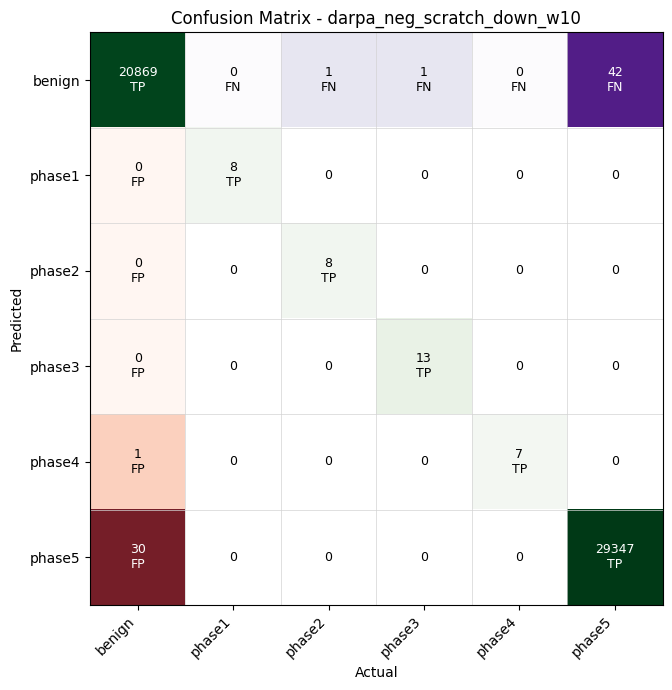

In [13]:
plot_confusion_matrix(mat, classes, experiment_name)

In [14]:
metrics

{'accuracy': np.float64(0.9985097462594631),
 'macro_precision': 0.9747957585866495,
 'macro_recall': 0.9632062422664347,
 'macro_f1': 0.9672495137281298,
 'false_alarms': 31,
 'false_alarm_rate': np.float64(0.0014832535885167463),
 'missed_attacks': 44,
 'detection_rate': np.float64(0.9985047745267951),
 'classes': ['benign', 'phase1', 'phase2', 'phase3', 'phase4', 'phase5'],
 'per_class': {'benign': {'TP': 20869,
   'FP': 44,
   'FN': 31,
   'precision': np.float64(0.9978960455219241),
   'recall': np.float64(0.9985167464114832),
   'f1': np.float64(0.9982062994762394),
   'support': 20900},
  'phase1': {'TP': 8,
   'FP': 0,
   'FN': 0,
   'precision': np.float64(1.0),
   'recall': np.float64(1.0),
   'f1': np.float64(1.0),
   'support': 8},
  'phase2': {'TP': 8,
   'FP': 0,
   'FN': 1,
   'precision': np.float64(1.0),
   'recall': np.float64(0.8888888888888888),
   'f1': np.float64(0.9411764705882353),
   'support': 9},
  'phase3': {'TP': 13,
   'FP': 0,
   'FN': 1,
   'precision': 